# Customer Churn Prediction using Machine Learning

## Project Overview

Customer churn prediction is one of the most important applications of machine learning in business. This project aims to predict whether a customer is likely to leave a telecom company based on their demographic information, account details, and subscribed services.

By identifying customers who are at risk of churning, businesses can take proactive measures to improve customer satisfaction and reduce revenue loss.

---

## Objectives

- Understand and explore the customer churn dataset.
- Perform data cleaning and preprocessing.
- Visualize important trends and relationships.
- Train multiple machine learning models.
- Compare model performance.
- Predict customer churn accurately.

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

# Import Required Libraries

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score

# Load the Dataset

In [29]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


# Explore the Dataset

In [30]:
df = pd.read_csv('archive.zip')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

Shape of Dataset:
(7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-nul

# Data Cleaning and Preprocessing

In [32]:
df.drop('customerID', axis=1, inplace=True)

In [33]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [34]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

# Exploratory Data Analysis (EDA)

In [35]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

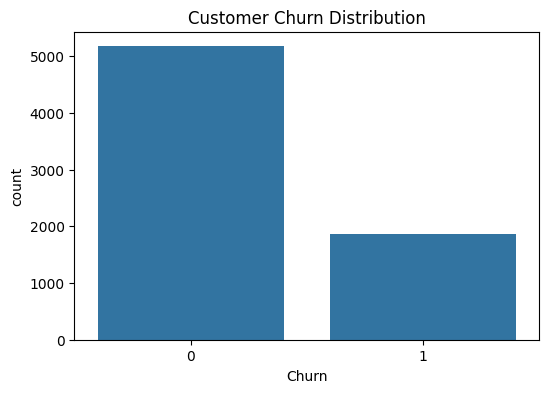

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.show()

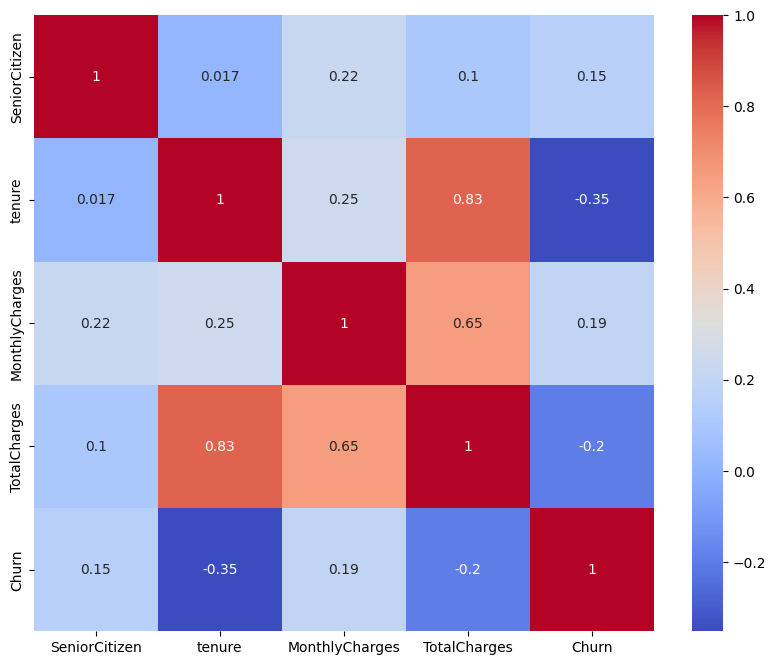

In [37]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Feature Engineering

In [38]:
categorical_cols = df.select_dtypes(
    include='object'
).columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [39]:
X = df.drop('Churn', axis=1)

y = df['Churn']

# Split Data into Training and Testing Sets

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


# Train the Random Forest Model

In [41]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [42]:
y_pred = rf_model.predict(X_test)

# Model Comparison

In [43]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([name, accuracy])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.799148
3,Random Forest,0.792051
2,K-Nearest Neighbors,0.765082
1,Decision Tree,0.730305


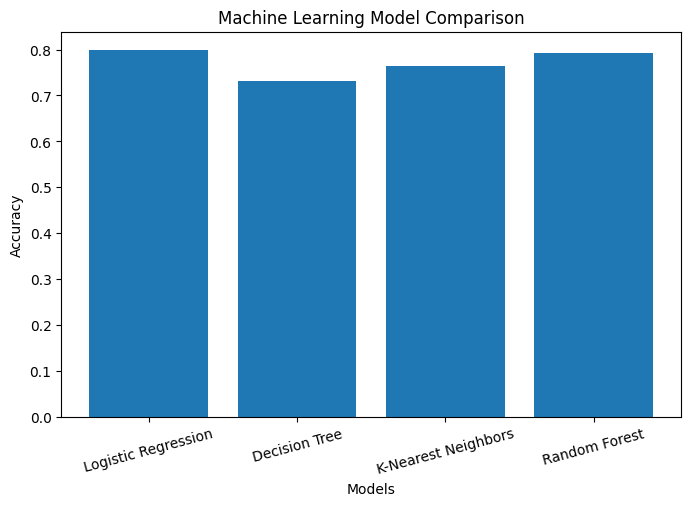

In [44]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

# Detailed Model Evaluation

In this section, we evaluate the performance of the best-performing model using precision, recall, F1-score, confusion matrix, and ROC curve.

In [45]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 79.21 %


In [46]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



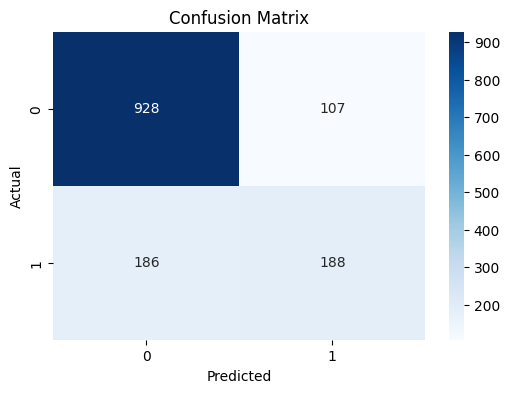

In [47]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

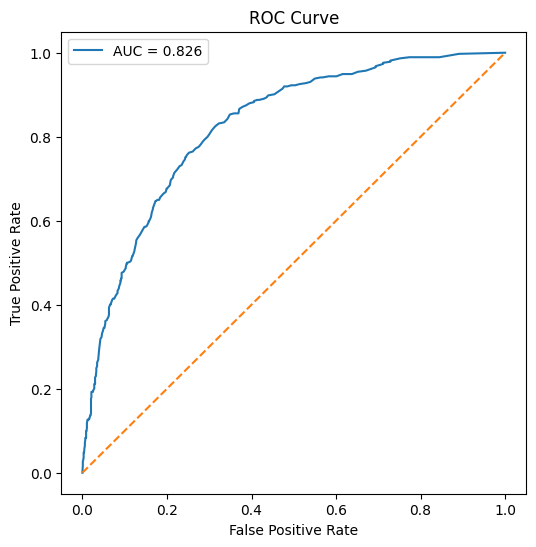

In [52]:
# Predict probabilities
y_prob = rf_model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = rf_model.predict(X_test)

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

metrics

,Metric,Score
0,Accuracy,0.789212
1,Precision,0.633218
2,Recall,0.489305
3,F1 Score,0.552036


# Feature Importance Analysis

In [48]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

            Feature  Importance
18     TotalCharges    0.188114
17   MonthlyCharges    0.178972
4            tenure    0.157034
14         Contract    0.076977
16    PaymentMethod    0.050554
8    OnlineSecurity    0.050154
11      TechSupport    0.041208
0            gender    0.027901
7   InternetService    0.027594
9      OnlineBackup    0.026865


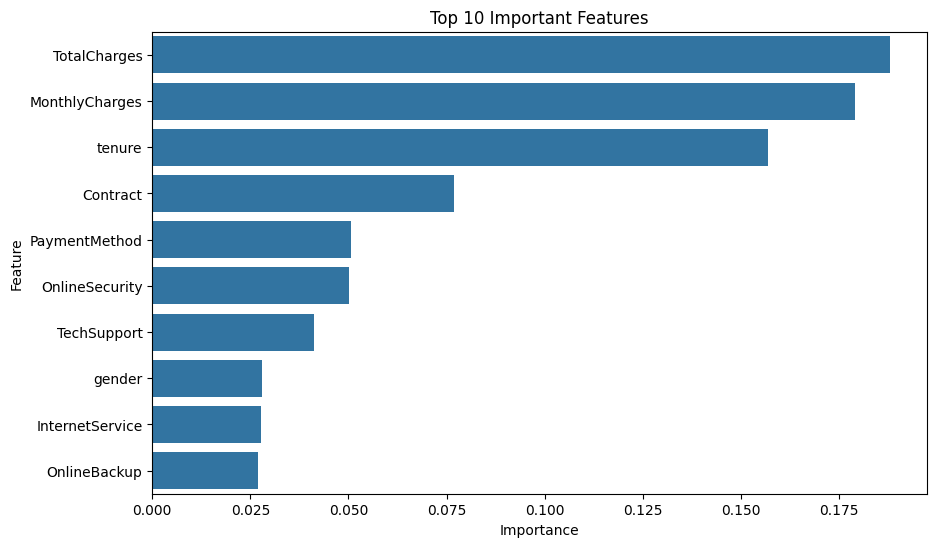

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

# Sample Prediction

In [50]:
sample_customer = X.iloc[0:1]

prediction = rf_model.predict(
    sample_customer
)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Not Churn")

Customer Will Not Churn


# Save the Trained Model

In [51]:
import joblib

joblib.dump(
    rf_model,
    'customer_churn_model.pkl'
)

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

In this project, we developed a machine learning model to predict customer churn using a telecom customer dataset. The data was cleaned, preprocessed, and analyzed to identify important patterns affecting customer retention.

Multiple machine learning algorithms, including Logistic Regression, Decision Tree, K-Nearest Neighbors, and Random Forest, were trained and compared. Among these models, the Random Forest classifier achieved the best overall performance and was selected as the final model.

The trained model can help businesses identify customers who are likely to leave, allowing them to implement targeted retention strategies and improve customer satisfaction.

## Future Improvements

- Perform hyperparameter tuning to improve model performance.
- Handle class imbalance using techniques such as SMOTE.
- Deploy the model as a web application using Streamlit or Flask.
- Integrate the model into a real-time customer management system.